<a href="https://colab.research.google.com/github/Lefty1995/Progetti-Epicode/blob/main/Progetto_Variational_Autoencoder_(VAE)_su_Flowers102.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device usato:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device usato: cuda
GPU: Tesla T4


In [3]:
IMG_SIZE = 64
BATCH_SIZE = 64
LATENT_DIM = 128
EPOCHS = 30
LEARNING_RATE = 1e-3

KL_WARMUP_EPOCHS = 10

DATA_DIR = "/content/data"
MODEL_PATH = "/content/vae_flowers102.pth"

In [4]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_dataset = datasets.Flowers102(
    root=DATA_DIR,
    split="train",
    download=True,
    transform=transform
)

print("Numero immagini nel dataset train:", len(train_dataset))

100%|██████████| 345M/345M [00:16<00:00, 21.1MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.86MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 38.8MB/s]


Numero immagini nel dataset train: 1020


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

images, labels = next(iter(train_loader))

print("Forma batch immagini:", images.shape)
print("Valore minimo pixel:", images.min().item())
print("Valore massimo pixel:", images.max().item())

Forma batch immagini: torch.Size([64, 3, 64, 64])
Valore minimo pixel: 0.0
Valore massimo pixel: 1.0


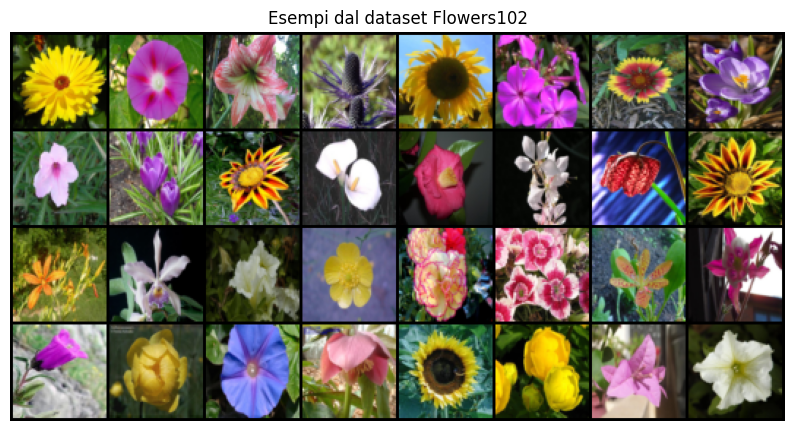

In [6]:
def show_images(tensor, title="Immagini"):
    tensor = tensor.detach().cpu()
    grid = make_grid(tensor, nrow=8, padding=2)

    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(title)
    plt.axis("off")
    plt.show()

show_images(images[:32], title="Esempi dal dataset Flowers102")

In [7]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()

        self.latent_dim = latent_dim

        # Encoder: immagine 3x64x64 -> feature compresse
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),   # 32x32x32
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 64x16x16
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 128x8x8
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # 256x4x4
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

        self.flatten_dim = 256 * 4 * 4

        # Due rami finali: media e log-varianza
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # Parte iniziale del decoder
        self.fc_decode = nn.Linear(latent_dim, self.flatten_dim)

        # Decoder: spazio latente -> immagine 3x64x64
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # 128x8x8
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # 64x16x16
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # 32x32x32
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1), # 3x64x64
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon
        return z

    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(x.size(0), 256, 4, 4)
        x = self.decoder(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)

        return reconstruction, mu, logvar

In [8]:
def vae_loss(reconstructed, original, mu, logvar, beta=1.0):
    # Reconstruction Loss
    reconstruction_loss = F.mse_loss(
        reconstructed,
        original,
        reduction="sum"
    ) / original.size(0)

    # KL Divergence
    kl_divergence = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    ) / original.size(0)

    # Loss totale
    total_loss = reconstruction_loss + beta * kl_divergence

    return total_loss, reconstruction_loss, kl_divergence

In [9]:
model = VAE(latent_dim=LATENT_DIM).to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print(model)

VAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
  )
  (fc_mu): Linear(in_features=4096, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=4096, out_features=128, bias=True)
  (fc_decode): Linear(in_features=128, out_features=4096, bias=True)
  (decoder): Sequential(
    (0): Con

In [10]:
history = {
    "total_loss": [],
    "reconstruction_loss": [],
    "kl_divergence": [],
    "beta": []
}

for epoch in range(1, EPOCHS + 1):

    model.train()

    total_loss_epoch = 0
    reconstruction_loss_epoch = 0
    kl_divergence_epoch = 0

    # KL Annealing
    beta = min(1.0, epoch / KL_WARMUP_EPOCHS)

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")

    for images, _ in progress_bar:
        images = images.to(device)

        optimizer.zero_grad()

        reconstructed, mu, logvar = model(images)

        loss, reconstruction_loss, kl_divergence = vae_loss(
            reconstructed,
            images,
            mu,
            logvar,
            beta=beta
        )

        loss.backward()
        optimizer.step()

        total_loss_epoch += loss.item()
        reconstruction_loss_epoch += reconstruction_loss.item()
        kl_divergence_epoch += kl_divergence.item()

        progress_bar.set_postfix({
            "loss": loss.item(),
            "recon": reconstruction_loss.item(),
            "kl": kl_divergence.item(),
            "beta": beta
        })

    avg_total_loss = total_loss_epoch / len(train_loader)
    avg_reconstruction_loss = reconstruction_loss_epoch / len(train_loader)
    avg_kl_divergence = kl_divergence_epoch / len(train_loader)

    history["total_loss"].append(avg_total_loss)
    history["reconstruction_loss"].append(avg_reconstruction_loss)
    history["kl_divergence"].append(avg_kl_divergence)
    history["beta"].append(beta)

    print(
        f"Epoch [{epoch}/{EPOCHS}] "
        f"Loss: {avg_total_loss:.4f} | "
        f"Recon: {avg_reconstruction_loss:.4f} | "
        f"KL: {avg_kl_divergence:.4f} | "
        f"Beta: {beta:.2f}"
    )

Epoch 1/30: 100%|██████████| 16/16 [00:05<00:00,  3.03it/s, loss=657, recon=639, kl=186, beta=0.1]


Epoch [1/30] Loss: 921.8903 | Recon: 885.9275 | KL: 359.6279 | Beta: 0.10


Epoch 2/30: 100%|██████████| 16/16 [00:02<00:00,  5.48it/s, loss=440, recon=414, kl=129, beta=0.2]


Epoch [2/30] Loss: 546.3331 | Recon: 516.6854 | KL: 148.2383 | Beta: 0.20


Epoch 3/30: 100%|██████████| 16/16 [00:02<00:00,  5.47it/s, loss=462, recon=431, kl=106, beta=0.3]


...

Epoch [28/30] Loss: 303.4092 | Recon: 237.7554 | KL: 65.6538 | Beta: 1.00


Epoch 29/30: 100%|██████████| 16/16 [00:03<00:00,  5.32it/s, loss=320, recon=256, kl=64.7, beta=1]


Epoch [29/30] Loss: 300.1241 | Recon: 233.4047 | KL: 66.7195 | Beta: 1.00


Epoch 30/30: 100%|██████████| 16/16 [00:03<00:00,  4.48it/s, loss=310, recon=249, kl=61.2, beta=1]

Epoch [30/30] Loss: 299.1826 | Recon: 233.0578 | KL: 66.1248 | Beta: 1.00


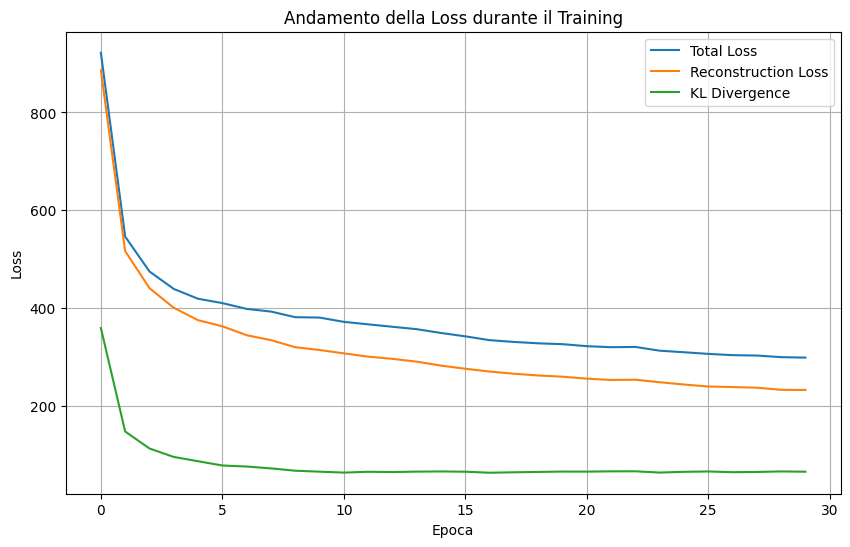

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(history["total_loss"], label="Total Loss")
plt.plot(history["reconstruction_loss"], label="Reconstruction Loss")
plt.plot(history["kl_divergence"], label="KL Divergence")

plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.title("Andamento della Loss durante il Training")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
torch.save(model.state_dict(), MODEL_PATH)

print("Modello salvato in:", MODEL_PATH)

Modello salvato in: /content/vae_flowers102.pth


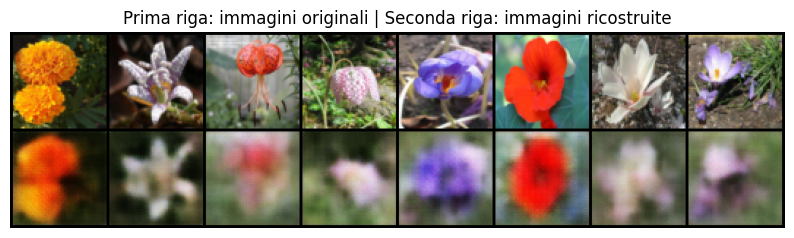

In [13]:
model.eval()

images, _ = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    reconstructed, mu, logvar = model(images)

# Prendiamo 8 immagini originali e 8 ricostruite
originals = images[:8].cpu()
reconstructions = reconstructed[:8].cpu()

comparison = torch.cat([originals, reconstructions])

show_images(
    comparison,
    title="Prima riga: immagini originali | Seconda riga: immagini ricostruite"
)

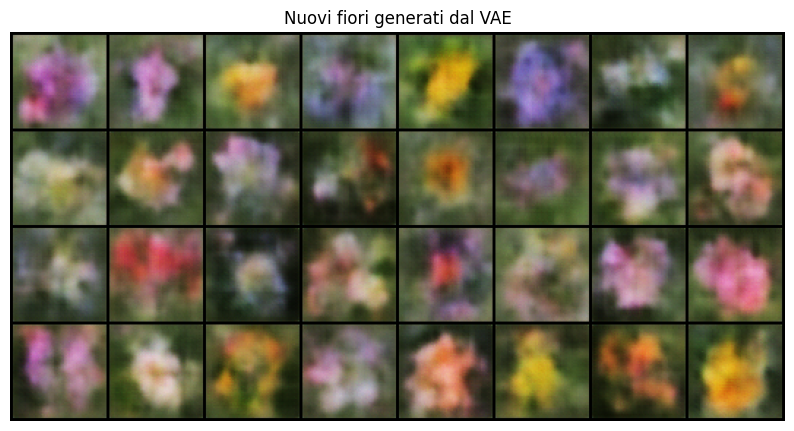

In [14]:
model.eval()

with torch.no_grad():
    z = torch.randn(32, LATENT_DIM).to(device)
    generated_images = model.decode(z)

show_images(
    generated_images.cpu(),
    title="Nuovi fiori generati dal VAE"
)

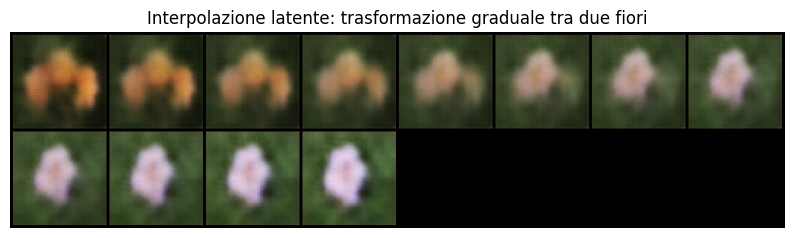

In [15]:
def interpolate_images(model, img1, img2, steps=10):
    model.eval()

    img1 = img1.unsqueeze(0).to(device)
    img2 = img2.unsqueeze(0).to(device)

    with torch.no_grad():
        mu1, logvar1 = model.encode(img1)
        mu2, logvar2 = model.encode(img2)

        z1 = mu1
        z2 = mu2

        interpolated_images = []

        for alpha in torch.linspace(0, 1, steps).to(device):
            z = (1 - alpha) * z1 + alpha * z2
            generated = model.decode(z)
            interpolated_images.append(generated.squeeze(0).cpu())

    return torch.stack(interpolated_images)


images, _ = next(iter(train_loader))

img1 = images[0]
img2 = images[1]

interpolated = interpolate_images(
    model=model,
    img1=img1,
    img2=img2,
    steps=12
)

show_images(
    interpolated,
    title="Interpolazione latente: trasformazione graduale tra due fiori"
)

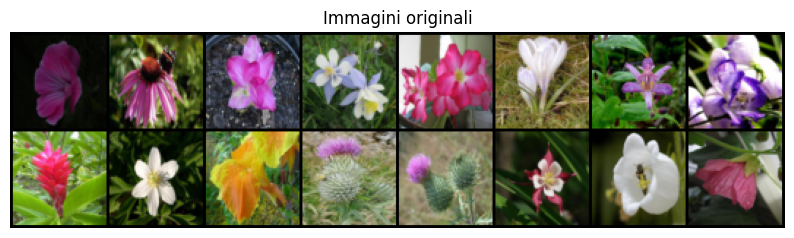

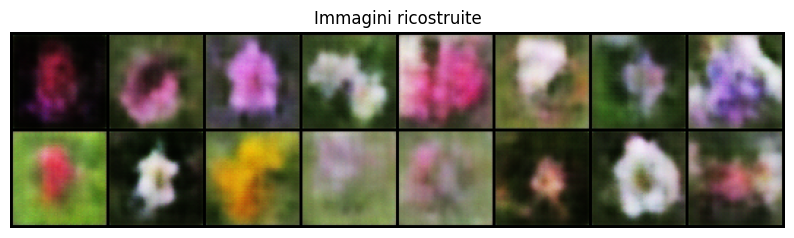

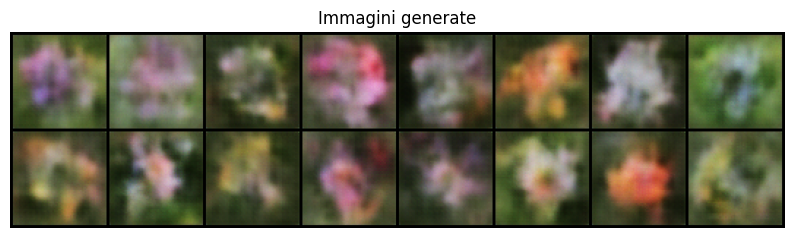

In [16]:
model.eval()

images, _ = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    reconstructed, _, _ = model(images)

    z = torch.randn(16, LATENT_DIM).to(device)
    generated = model.decode(z)

show_images(images[:16].cpu(), title="Immagini originali")
show_images(reconstructed[:16].cpu(), title="Immagini ricostruite")
show_images(generated.cpu(), title="Immagini generate")

In [17]:
from google.colab import files

files.download(MODEL_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>